STARR FROM THE BEGINING...I DONT KNOW WHAT WILL HAPPEN 

objective---

1-Complete structure, ready to be directly copied and run in a Jupyter Notebook

2-Includes both ViT and ResNet（One Notebook；Two Models；The Same Dataset；The Same Training Loop--Control variables:
Same Dataset
Same Split 
Same Loss 
Same Optimizer 
Same Epoch ）

3-Fully aligned with the regression objective outlined in your PDF

4-Freezes the backbone, training only the regression head

In [541]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import timm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter

In [542]:
data_dir = "dataset"

level_mapping = {
    "LEV0-Prototype": 1.0,
    "LEV1-Conservative_change": 0.9,
    "LEV2-Partially_change": 0.75,
    "LEV3-Completely_change_into_specific_items": 0.5,
    "LEV4-Almost_abstract_shape_with_a_bit_inherent_feature": 0.25,
    "LEV5-Completely_abstract": 0.1,
    "LEV6-NonCat": 0.0
}

image_paths = []
labels = []

for folder_name in level_mapping:
    folder_path = os.path.join(data_dir, folder_name)

    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(folder_path, file_name))
            labels.append(level_mapping[folder_name])

print("Distribution:", Counter(labels))

Distribution: Counter({0.75: 124, 0.25: 105, 0.0: 98, 0.5: 63, 1.0: 51, 0.1: 29, 0.9: 24})


In [543]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [544]:
class CatDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [545]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [546]:
train_dataset = CatDataset(train_paths, train_labels, transform)
val_dataset = CatDataset(val_paths, val_labels, transform)

class_counts = Counter(train_labels)
sample_weights = [1.0 / class_counts[label] for label in train_labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [547]:
class ResNetRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "resnet50",
            pretrained=True,
            num_classes=0
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        features = self.backbone(x)
        output = self.regressor(features)
        return output, features

In [548]:
class ViTRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        features = self.backbone(x)
        output = self.regressor(features)
        return output, features

In [549]:
def train_model(model, train_loader, epochs=8):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3
    )

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs, _ = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

    return model

In [550]:
def collect_outputs(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    preds = []
    labels = []
    features = []

    with torch.no_grad():
        for images, target in loader:
            images = images.to(device)
            outputs, feats = model(images)

            preds.extend(outputs.cpu().numpy().flatten())
            labels.extend(target.numpy())
            features.extend(feats.cpu().numpy())

    return np.array(preds), np.array(labels), np.array(features)

In [551]:
resnet_model = train_model(ResNetRegression(), train_loader)
vit_model = train_model(ViTRegression(), train_loader)

Epoch 1, Loss: 0.1306
Epoch 2, Loss: 0.0857
Epoch 3, Loss: 0.0744
Epoch 4, Loss: 0.0661
Epoch 5, Loss: 0.0582
Epoch 6, Loss: 0.0503
Epoch 7, Loss: 0.0446
Epoch 8, Loss: 0.0410
Epoch 1, Loss: 0.4679
Epoch 2, Loss: 0.2472
Epoch 3, Loss: 0.1334
Epoch 4, Loss: 0.0881
Epoch 5, Loss: 0.0630
Epoch 6, Loss: 0.0770
Epoch 7, Loss: 0.0670
Epoch 8, Loss: 0.0542


In [552]:
res_preds, res_labels, res_feats = collect_outputs(resnet_model, val_loader)
vit_preds, vit_labels, vit_feats = collect_outputs(vit_model, val_loader)

levels = sorted(set(res_labels))

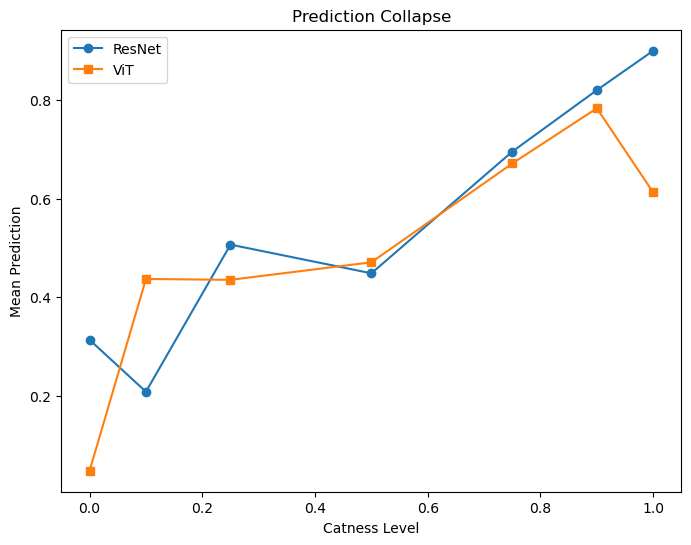

In [553]:
res_means = []
vit_means = []

for l in levels:
    res_means.append(res_preds[res_labels == l].mean())
    vit_means.append(vit_preds[vit_labels == l].mean())

plt.figure(figsize=(8,6))
plt.plot(levels, res_means, marker='o', label="ResNet")
plt.plot(levels, vit_means, marker='s', label="ViT")
plt.xlabel("Catness Level")
plt.ylabel("Mean Prediction")
plt.title("Prediction Collapse")
plt.legend()
plt.show()

In [554]:
def compute_distances(features, labels):
    centroid_0 = features[labels == 1.0].mean(axis=0)
    centroid_6 = features[labels == 0.0].mean(axis=0)

    dist_to_0 = []
    dist_to_6 = []

    for l in levels:
        f = features[labels == l]
        dist_to_0.append(np.linalg.norm(f - centroid_0, axis=1).mean())
        dist_to_6.append(np.linalg.norm(f - centroid_6, axis=1).mean())

    return dist_to_0, dist_to_6

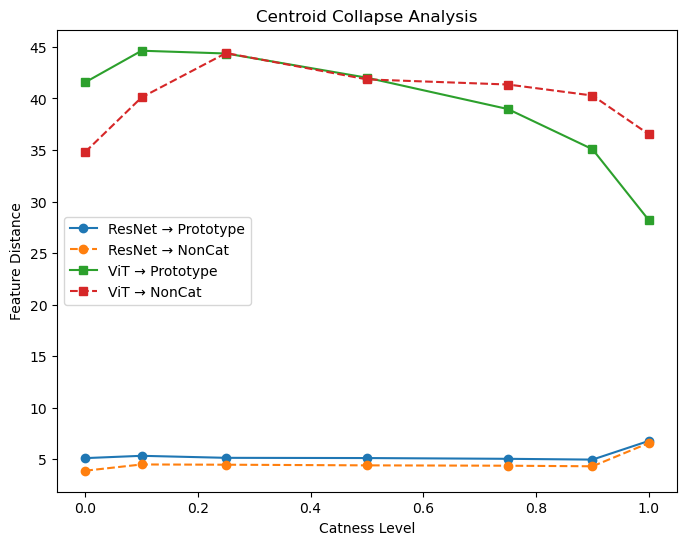

In [555]:
res_d0, res_d6 = compute_distances(res_feats, res_labels)
vit_d0, vit_d6 = compute_distances(vit_feats, vit_labels)

plt.figure(figsize=(8,6))
plt.plot(levels, res_d0, marker='o', label="ResNet → Prototype")
plt.plot(levels, res_d6, marker='o', linestyle='--', label="ResNet → NonCat")

plt.plot(levels, vit_d0, marker='s', label="ViT → Prototype")
plt.plot(levels, vit_d6, marker='s', linestyle='--', label="ViT → NonCat")

plt.xlabel("Catness Level")
plt.ylabel("Feature Distance")
plt.title("Centroid Collapse Analysis")
plt.legend()
plt.show()